**Classification**                                                       
Méthodes K-means et CAH et visualisation de la classification avec l'ACP

In [ ]:
import pandas
#Stat - librairie numpy
import numpy as np
#scikit-learn
import sklearn
#scree plot
import matplotlib.pyplot as plt
X = pandas.read_excel("/content/Pays_ecolo7 (1).xls",sheet_name="Feuil12",header=0,index_col=0)
print(X)
print(X.describe())

                                 Terres_ag  Superf_urbaine   Retr_eau  \
Country                                                                 
Angola                           36.810780     2991.346987   0.705700   
Albanie                          42.538504      827.693957   0.786000   
Émirats arabes unis               5.488595     2263.105046   2.381000   
Arménie                          58.868985      922.335027   2.830000   
Australie                        46.252480    11945.986037   8.640000   
...                                    ...             ...        ...   
Saint-Vincent-et-les Grenadines  17.948718       68.762648   0.007900   
Viet Nam                         39.434768    28615.406060  81.862000   
Afrique du Sud                   79.417850    15118.662080  20.310000   
Zambie                           32.067959     2079.135102   1.572000   
Zimbabwe                         41.876696     2024.485897   3.771382   

                                 Stress_hydrique  

Classification CAH et visualisation de la partition finale  avec ACP

                 Country
1                 Brésil
1             Bangladesh
1              Indonésie
1   Fédération de Russie
2                 Chypre
..                   ...
7                  Japon
7            Royaume-Uni
7                 France
7              Allemagne
7                Espagne

[119 rows x 1 columns]
                                 Classe  Terres_ag  Superf_urbaine   Retr_eau  \
Country                                                                         
Angola                                3  36.810780     2991.346987   0.705700   
Albanie                               3  42.538504      827.693957   0.786000   
Émirats arabes unis                   6   5.488595     2263.105046   2.381000   
Arménie                               3  58.868985      922.335027   2.830000   
Australie                             6  46.252480    11945.986037   8.640000   
...                                 ...        ...             ...        ...   
Saint-Vincent-et-les Grenadi

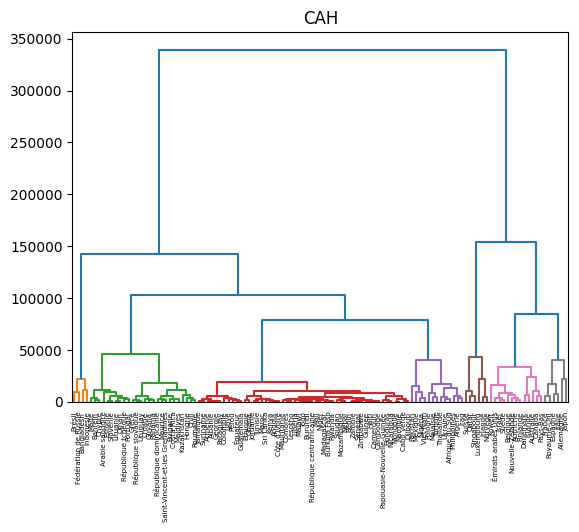

In [ ]:
#librairies pour la CAH
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram , linkage, fcluster

#générer la matrice des liens
Z = linkage(X,method='ward',metric='euclidean')

#affichage du dendrogramme
plt.title("CAH")
#découpage à la hauteur 300 ==> identifiants de 4 groupes obtenus
dendrogram(Z,labels=X.index,color_threshold =60000)
plt.show
groupes_cah= fcluster(Z,t =60000,criterion ='distance')

#index triés des groupes
idg = np.argsort (groupes_cah)
#affichage des observations et leurs groupes
print(pandas.DataFrame(X.index[idg],groupes_cah[idg]))

#affichage des observations et leurs groupes
cl=pandas.DataFrame({'Classe':groupes_cah,'Terres_ag':X.Terres_ag,'Superf_urbaine':X.Superf_urbaine,'Retr_eau':X.Retr_eau,'Stress_hydrique':	X.Stress_hydrique,'CO2_hab':	X.CO2_hab,'Elect_renouv': X.Elect_renouv,'Accès_élect': X.Accès_élect,'Hauteur_précip':	X.Hauteur_précip, 'PIB_hab': X.PIB_hab})
print(cl)
gr = cl.groupby('Classe')
print(gr.count())
print(gr.mean())



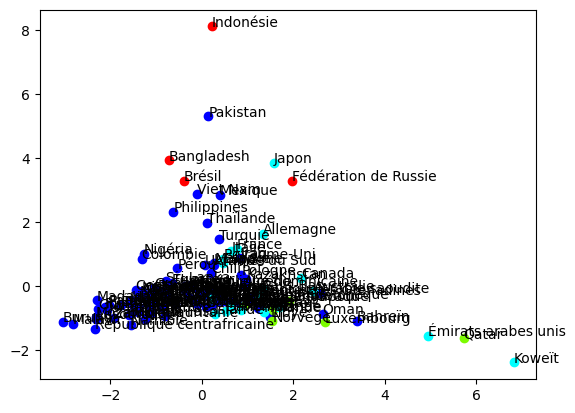

In [ ]:
########################ACP
from sklearn.preprocessing import StandardScaler
#instanciation
sc = StandardScaler()
#transformation – centrage-réduction
Z = sc.fit_transform(X)

from sklearn.decomposition import PCA
acp= PCA(n_components =2).fit_transform(Z)

#projeter dans le plan factoriel
#avec un code couleur différent selon le groupe
#remarquer le rôle de zip() dans la boucle
import matplotlib.pyplot as plt
for couleur,k in zip([ 'red','blue','lawngreen','aqua'],[1,2,3,4]):
    plt.scatter(acp[groupes_cah==k,0], acp[groupes_cah==k,1],c=couleur)

n = X.shape[0]
#mettre les labels des points
for i in range(n):
    plt.annotate(X.index[i],(acp[i,0], acp[i,1]))
plt.show()